In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/stranger-things-trailer-youtube-comments/youtube_comments.csv
/kaggle/input/manual-data/manually_labelled_sample_data.csv


In [5]:
# importing libraries

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [6]:
data = pd.read_csv("/kaggle/input/stranger-things-trailer-youtube-comments/youtube_comments.csv")
data.head()

,comment_id,author,text,likes,published_at
0,UgwoiJ6zDlEHgNHbKHl4AaABAg,@SalekaAsuna,Mike is the most traumatic in this season his ...,0,2025-12-27T02:17:44Z
1,UgyXJRcSbn74ajhkmBN4AaABAg,@tofuzu,"this was so bad yall. wth was that writing, th...",0,2025-12-27T02:13:56Z
2,UgzhXrqNFCkMLMOB6dh4AaABAg,@JD-xn1cx,Not a single shot from final episode,0,2025-12-27T01:51:33Z
3,UgxQPzUbRC8ECcXroFF4AaABAg,@ravenr876,Rated J for Jesus: A Box Office Blasphemy – Ho...,0,2025-12-27T01:35:21Z
4,UgzQIyIMuD3WZha30dd4AaABAg,@ravenr876,Does Hollyweird ever stop attacking Christiani...,0,2025-12-27T01:30:37Z


In [7]:
data["text"] = data["text"].str.strip()

# removing empty comments
data = data[data["text"].notnull() & (data["text"] != "")]

# removing URLs
import re
data["text"] = data["text"].apply(lambda x: re.sub(r"http\S+", "", x))

# VADER SENTIMENT ANALYSIS
- gives a score for positive, negative and neutral sentiment indicating how poswitive, negative or neutral the text is.
- also gives a combined score that averages out the scores for the three sentiments
- it doesn't account
       * relationships between words which can convey meaningful info
      *  doesn't account for slang or sarcasm - where words have different literal meaning and a different intention or meaning in context
- In this model, stop words are removed and bag of words approach is used. Then, each word is scored and a combined scored is given.

In [8]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

# creating a Sentiment Intensity Analyzer Object
sia = SentimentIntensityAnalyzer()

In [5]:
data["text"].sample().values[0]

'The most fearful thing is going to happen we cant do anything dustin and harrington 😢😢😢😢😢😢'

In [37]:
# testing Sentiment Intensity Analyzer
sample = data["text"].sample().values[0]
print(sample)
sia.polarity_scores(sample)

Everyone die 😢 if die


{'neg': 0.796, 'neu': 0.204, 'pos': 0.0, 'compound': -0.8316}

### OBSERVATIONS
1. works well in some cases
2. but in cases where the spelling isn't grammatical say, "dis is great". it assigns it a negative meaning and can't detect the positivity. This is however, one of the limitations of NLP wherein they only recognize words that are spelled correctly.

In [9]:
# run the polarity score on entire dataset
res = {}

for i, row in tqdm(data.iterrows(), total=len(data)):
    text = row["text"]
    myid = row["comment_id"]
    res[myid] = sia.polarity_scores(text)

  0%|          | 0/19821 [00:00<?, ?it/s]

In [10]:
# converting the results dictionary to a dataframe
vaders =pd.DataFrame(res).T

In [11]:
# resetting index and renaming it to comment_id
vaders = vaders\
        .reset_index()\
        .rename(columns={"index" : "comment_id"})

In [41]:
vaders.shape

(19821, 5)

In [12]:
# merging vaders and data dataframes
data_with_vaders = pd.merge(vaders, data, on="comment_id")

### How to convert VADER sentiment scores to a sentiment label
- VADER gives a score each for positive, negative and neutral sentiments and then also gives a compound score.
- Compound score is a normalized score in the range [-1,1].
- It is recommneded that compound score be used to convert scores to labels.

<b>Why not use raw scores for each of the three sentiments to assign a sentiment label?</b>
- they don’t capture intensity
- A comment can have high pos and neg
- No clear thresholding rule
- Not recommended in the VADER paper

In [15]:
data_with_vaders.columns

Index(['comment_id', 'neg', 'neu', 'pos', 'compound', 'author', 'text',
       'likes', 'published_at'],
      dtype='object')

In [46]:
print(data_with_vaders["compound"].min(), data_with_vaders["compound"].max())

-0.9997 1.0


In [13]:
# CONVERTING VADER compound scores to sentiment labels
def vader_label(compound):
    if compound >= 0.05:
        return "positive"
    elif compound <= -0.05:
        return "negative"
    else:
        return "neutral"

In [14]:
data_with_vaders["vader_label"] = data_with_vaders["compound"].apply(vader_label)

Now, since VADER is unsupervised, accuracy isn't automatic. We need a reference (ground truth) or proxy. <Br>
we have to check  how accurate this labelling was.<Br>
Method 1. I'm gonna sample 500 reviews and mnaually label them as positive, negative and neutral.<Br>
Method 2: I'm gonna use LLM. Roberta by Hugging Face.<Br>

In [15]:
sample_data = data.sample(500, random_state=42)

In [11]:
# exporting the sample data as a csv
sample_data.to_csv("sample_data.csv", index=False)

### Obswervations while manually labelling data
1. a lot of it is positive or neutral
2. fans are either commenting very positive things about the trailer or are commenting fan theories or just mentioning the facts that they dont want certain things to happen like certain characters to die.
3. some comments are not in english so im labelling them neutral
4. since emojis are not captured in csv files, a lot of the "EMOTION" of the comment goes away so thats some information we cant access.
5. slang is used like "dis dope" or "shiiii" or "oh dawg" which I understood as a human but our algorithms are gonna have a tough time recognizing this.

In [16]:
sample_data_manually_labelled = pd.read_csv("/kaggle/input/manual-data/manually_labelled_sample_data.csv")
sample_data_manually_labelled

,manually_labelled_snetiment,comment_id,author,text,published_at,likes
0,positive,UgzQ_o-sx7vNjVg27oh4AaABAg,@two_shoes-t7x,I sure love getting dripfed different episodes🤠,2025-12-17T14:15:16Z,0
1,neutral,Ugye2D4eKojLGbDigLd4AaABAg,@thebestleaderinthefuture4851,"Whoever thinks Dustin and Steve won't die, let...",2025-12-16T06:22:43Z,23
2,positive,UgwtG7hViLuWR3-orUd4AaABAg,@savannahbanana7421,Can't wait,2025-12-15T16:47:21Z,1
3,positive,UgzD-G8scZ8C5LKD_qh4AaABAg,@vlogsandetc,HOLLY MAX NANCY AND EL ARE GOING TO SMOKE EVER...,2025-12-15T22:58:27Z,1
4,positive,Ugwog5BI00mdosOUSS14AaABAg,@ContaMinha-t8c,AAAAAAAAAAAAAAAAA AAAAAAAAAAAAAAAAA AAAAAAAAAA...,2025-12-15T14:21:11Z,0
...,...,...,...,...,...,...
495,positive,Ugy8ZdTSi66wyEeAzmd4AaABAg,@vincemartinez1666,So we getting new upside down rules and reveal...,2025-12-15T13:49:03Z,0
496,positive,UgzwhyFHwvAH8lYM7kB4AaABAg,@gw_mandeep_yt7790,It will a game-changer,2025-12-15T16:08:21Z,0
497,positive,UgxDAg77S7_R3hRb8jp4AaABAg,@iamsrg_24_7,Yeaaahhhhhhhh❤,2025-12-15T13:51:00Z,0
498,positive,UgxfjFUyQGSQ-z2ek-Z4AaABAg,@Noasark27,This version of the song is so peak,2025-12-15T23:43:59Z,0


In [14]:
data.columns

Index(['comment_id', 'author', 'text', 'likes', 'published_at'], dtype='object')

In [17]:
# fix some errors in the manually labelled data

# renaming a column
sample_data_manually_labelled.rename(
    columns={"manually_labelled_snetiment" : "manual_label"
},  inplace=True)


# fixing spelling errors in manual_label column
sample_data_manually_labelled["manual_label"] = (
    sample_data_manually_labelled["manual_label"]
    .str.strip()          # remove extra spaces
    .str.lower()          # lowercase
    .replace({
        "positiive": "positive",
        "posiive": "positive",
        "netural": "neutral",
        "neautral": "neutral",
        "negitive": "negative"
    }))


# filling a NaN value in manual_label
sample_data_manually_labelled.iloc[294, 0] = "positive"

In [18]:
# data with both manual labels and VADER labels for 500 samples

merged_sample_data = sample_data_manually_labelled.merge(data_with_vaders[["comment_id","vader_label"]], on="comment_id", how="left")

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
report_vader = classification_report(merged_sample_data["manual_label"], merged_sample_data["vader_label"], output_dict=True)
report_vader

              precision    recall  f1-score   support

    negative       0.07      0.52      0.12        21
     neutral       0.59      0.39      0.47       313
    positive       0.43      0.33      0.37       166

    accuracy                           0.38       500
   macro avg       0.36      0.42      0.32       500
weighted avg       0.51      0.38      0.42       500



# Interpretation of the results
- overall accuracy of 38%

- <B>NEGATIVE CLASS</B>
      - precision of 0.07 - very low
      - recall - 0.52- decent

      - VADER overpredicts negative comments
     - is able to correctly classify 52% of the negative comments
     - many comments that it flags as negative are actually positive or neutral

 - <B>POSITIVE CLASS</B>
        - precision - 0.43 , recall - 0.33
        - misses a lot of true positives


 - <B>NEUTRAL CLASS</B>
        - precision - 0.59 , recall - 0.39
        - VADER struggles with neutral language
        - often tries to push weak sentiments into positive or negative sentiment

- During manual labelling of 500 comments, I observed that a good proportion of the comments were fan theories or fans acknowleding certain plotlines or character appearnaces which isn't necessarily positive or negative. I think this is where VADER struggled to classify text into either of these sentiments.

- Also, interpreting slang and emoji also provides useful insights into the sentiment of texts but since VADER cant process them, it misses out on that information.

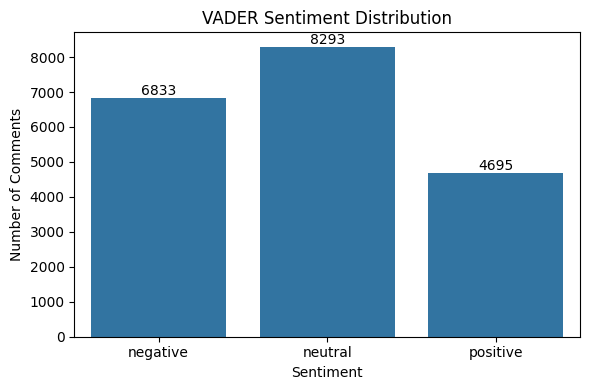

In [20]:
# visualizing vader results
counts = (
    data_with_vaders["vader_label"]
    .value_counts()
    .reindex(["negative", "neutral", "positive"])
    .reset_index()
)

counts.columns = ["Sentiment", "Count"]

# Plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=counts,
    x="Sentiment",
    y="Count"
)

# Add count labels on bars
for bar in ax.patches:
    ax.annotate(
        int(bar.get_height()),
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.title("VADER Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

### USING Roberta
- trained using a large corpus of data
- accounts for words and the context related to other words

In [21]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from scipy.special import softmax

2025-12-28 19:03:27.301032: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766948607.528962      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766948607.591472      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766948608.136090      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766948608.136183      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766948608.136187      55 computation_placer.cc:177] computation placer alr

In [22]:
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [24]:
# VADER prediction

example = data_with_vaders["text"].sample().values[0]
print(example)
sia.polarity_scores(example)

I know nobody cares,
but Murray, like if anyone kills them,
I wanna cook their a**


{'neg': 0.226, 'neu': 0.524, 'pos': 0.25, 'compound': -0.128}

In [28]:
encoded_text= tokenizer(example, return_tensors="pt")
output = model(**encoded_text)
scores = output[0][0].detach().numpy()
scores = softmax(scores)


# priting scores in a dictionary
roberta_scores = {
    "roberta_neg" : float(scores[0]),
    "roberta_neu" : float(scores[1]),
    "roberta_pos" : float(scores[2])
}

0.9176278710365295

# VADERS VS. ROBERTA
- Sample text : This is going to be an incredibly crazy
- VADER : compound score of -.4005 - might be assigning a negative connotation to crazy
- ROBERTA - positive score of 0.9176
- This indicates that Roberta is able to understand context of words. 

In [29]:
# applying roberta to entire dataset
def polarity_scores_roberta(text): 
    """Takes a text string. uses Roberta to run sentiment analysis on it. Returns a dictionary of polarity scores : negative, neutral, positive"""
    encoded_text = tokenizer(text, return_tensors="pt")
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    
    
    # priting scores in a dictionary
    roberta_scores = {
        "roberta_neg" : float(scores[0]),
        "roberta_neu" : float(scores[1]),
        "roberta_pos" : float(scores[2])
    }

    return roberta_scores

In [34]:
res = {}

for i, row in tqdm(data.iterrows(), total=len(data)):
    try:
        text = row["text"]
        myid = row["comment_id"]
        vader_result = sia.polarity_scores(text)
    
        # renaming vader result values
        vader_result_rename = {}
        for key, value in vader_result.items():
            vader_result_rename[f"vader_{key}"] = value
        roberta_result = polarity_scores_roberta(text)
    
        # combining both resutls
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both

    except RuntimeError:    # Roberta cant tackle texts with more than 514 characters
        print(f"Broke for id {myid}")

  0%|          | 0/19821 [00:00<?, ?it/s]

Broke for id UgzBLtEI1FuuriruFRh4AaABAg
Broke for id UgyG_BhV1Yn3Zqozd794AaABAg


In [35]:
len(res)

19819

In [36]:
results_df = pd.DataFrame(res).T.reset_index().rename(columns = {"index" : "comment_id"})

In [37]:
labelled_data = data.merge(results_df, on="comment_id")

In [40]:
# converting vader compound score to sentiment label
def vader_compound_to_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

labelled_data['vader_label'] = labelled_data['vader_compound'].apply(vader_compound_to_label)


In [41]:
# converting roberta scores to sentiment labels
labels = np.array(['negative', 'neutral', 'positive'])

labelled_data['roberta_label'] = labels[
    np.argmax(
        labelled_data[['roberta_neg', 'roberta_neu', 'roberta_pos']].values,
        axis=1
    )
]

In [46]:
# exporting the labelled data : original data + vader scores for each sentiment + roberta scores for each sentiment
labelled_data.to_csv("labelled_data.csv")

In [175]:
# Select relevant columns
df_plot = labelled_data[['vader_neg', 'vader_neu', 'vader_pos',
                'roberta_neg', 'roberta_neu', 'roberta_pos']]

# Melt the DataFrame to long format for seaborn
df_melt = pd.melt(
    df_plot.reset_index(),
    id_vars='index',
    value_vars=['vader_neg','vader_neu','vader_pos',
                'roberta_neg','roberta_neu','roberta_pos'],
    var_name='model_sentiment',
    value_name='score'
)

# Split model and sentiment into separate columns
df_melt['model'] = df_melt['model_sentiment'].apply(lambda x: x.split('_')[0].capitalize())
df_melt['sentiment'] = df_melt['model_sentiment'].apply(lambda x: x.split('_')[1].capitalize())


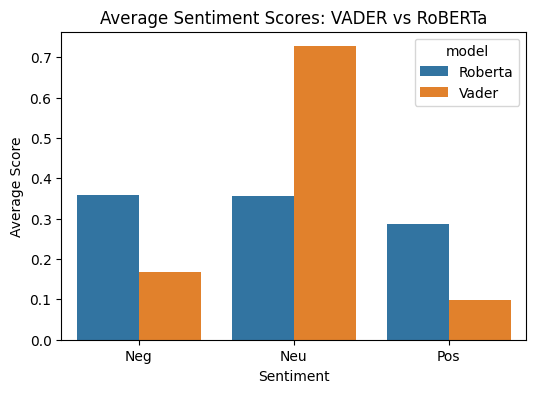

In [176]:
# Compute mean scores
mean_scores = df_melt.groupby(['sentiment','model'])['score'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=mean_scores, x='sentiment', y='score', hue='model')
plt.title("Average Sentiment Scores: VADER vs RoBERTa")
plt.ylabel("Average Score")
plt.xlabel("Sentiment")
plt.show()


### OBSERVATIONS
1. VADER : disproportionately high number of neutral classfications, followed by negative and neutral
   RoBERTa : roughly equal number of positive, negative and neutral

2. indicats that VADER is lexicon based (has a specific list of words and rules that it uses)

       - struggles with slang and sarcasm

       - classifies weak emotional texts as neutral


3. RoBERTa - transformer-based, understands context

       - can detect nuances in emotions that VADER might miss out on

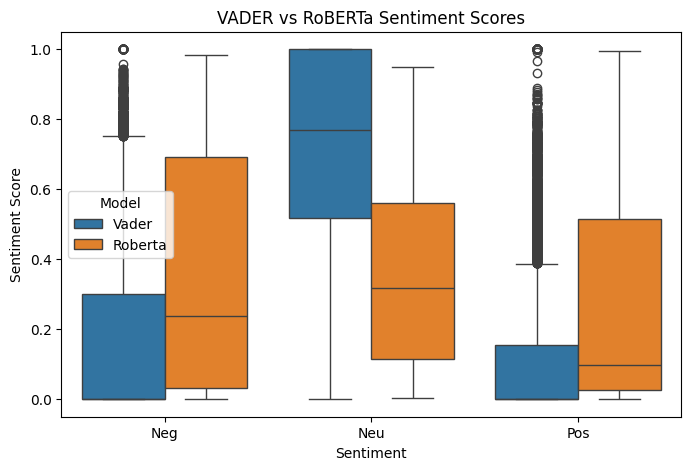

In [177]:
# Plot
plt.figure(figsize=(8,5))
sns.boxplot(data=df_melt, x='sentiment', y='score', hue='model')
plt.title("VADER vs RoBERTa Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.xlabel("Sentiment")
plt.legend(title="Model")
plt.show()

In [179]:
labelled_data.columns

Index(['comment_id', 'author', 'text', 'likes', 'published_at', 'vader_neg',
       'vader_neu', 'vader_pos', 'vader_compound', 'roberta_neg',
       'roberta_neu', 'roberta_pos'],
      dtype='object')

- create a dataframe with  vader and roberta predictions for the sample and the entire data
- export hte sample data file to csv
- 

### USING HUGGING FACE PIPELINE


In [47]:
from transformers import pipeline
sent_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [48]:
print(example)
sent_pipeline(example)

I know nobody cares,
but Murray, like if anyone kills them,
I wanna cook their a**


[{'label': 'NEGATIVE', 'score': 0.9982945322990417}]

In [49]:
sent_pipeline(example)[0]["label"].lower()

'negative'

In [50]:
def apply_pipeline(text):
    return sent_pipeline(text)[0]["label"].lower()

res = {}
for i, row in tqdm(data.iterrows(), total=len(data)):
    try: 
        text = row["text"]
        myid = row["comment_id"]
        sentiment = apply_pipeline(text)
        res[myid] = sentiment
    except RuntimeError:
        print(f"Broke for {myid}")

  0%|          | 0/19821 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (642 > 512). Running this sequence through the model will result in indexing errors


Broke for UgyG_BhV1Yn3Zqozd794AaABAg


In [58]:
pipeline_labels = pd.DataFrame(
    list(res.items()),
    columns=['comment_id', 'sentiment_label']
)

In [60]:
labelled_data = labelled_data.merge(pipeline_labels, on="comment_id").rename(columns= {
    "sentiment_label" : "pipeline_label"
})

In [61]:
labelled_data.head()

,comment_id,author,text,likes,published_at,vader_neg,vader_neu,vader_pos,vader_compound,roberta_neg,roberta_neu,roberta_pos,vader_label,roberta_label,pipeline_label
0,UgwoiJ6zDlEHgNHbKHl4AaABAg,@SalekaAsuna,Mike is the most traumatic in this season his ...,0,2025-12-27T02:17:44Z,0.128,0.818,0.054,-0.5314,0.971900,0.025935,0.002164,negative,negative,negative
1,UgyXJRcSbn74ajhkmBN4AaABAg,@tofuzu,"this was so bad yall. wth was that writing, th...",0,2025-12-27T02:13:56Z,0.278,0.722,0.000,-0.9460,0.975026,0.022050,0.002924,negative,negative,negative
2,UgzhXrqNFCkMLMOB6dh4AaABAg,@JD-xn1cx,Not a single shot from final episode,0,2025-12-27T01:51:33Z,0.000,1.000,0.000,0.0000,0.390147,0.579394,0.030459,neutral,neutral,negative
3,UgxQPzUbRC8ECcXroFF4AaABAg,@ravenr876,Rated J for Jesus: A Box Office Blasphemy – Ho...,0,2025-12-27T01:35:21Z,0.167,0.833,0.000,-0.2960,0.299472,0.592630,0.107898,negative,neutral,positive
4,UgzQIyIMuD3WZha30dd4AaABAg,@ravenr876,Does Hollyweird ever stop attacking Christiani...,0,2025-12-27T01:30:37Z,0.382,0.618,0.000,-0.9186,0.972716,0.024830,0.002454,negative,negative,positive


In [62]:
# exporting labelled data as csv.
labelled_data.to_csv("labelled_data.csv")

In [80]:
df_merged = sample_data_manually_labelled[["comment_id","text", "manual_label"]].merge(labelled_data, on="comment_id", how="left")

In [86]:
df_merged[["comment_id", "text_x", "manual_label", "vader_label", "roberta_label", "pipeline_label"]]

,comment_id,text_x,manual_label,vader_label,roberta_label,pipeline_label
0,UgzQ_o-sx7vNjVg27oh4AaABAg,I sure love getting dripfed different episodes🤠,positive,positive,positive,negative
1,Ugye2D4eKojLGbDigLd4AaABAg,"Whoever thinks Dustin and Steve won't die, let...",neutral,positive,neutral,negative
2,UgwtG7hViLuWR3-orUd4AaABAg,Can't wait,positive,neutral,positive,positive
3,UgzD-G8scZ8C5LKD_qh4AaABAg,HOLLY MAX NANCY AND EL ARE GOING TO SMOKE EVER...,positive,neutral,neutral,positive
4,Ugwog5BI00mdosOUSS14AaABAg,AAAAAAAAAAAAAAAAA AAAAAAAAAAAAAAAAA AAAAAAAAAA...,positive,neutral,neutral,negative
...,...,...,...,...,...,...
495,Ugy8ZdTSi66wyEeAzmd4AaABAg,So we getting new upside down rules and reveal...,positive,negative,neutral,negative
496,UgzwhyFHwvAH8lYM7kB4AaABAg,It will a game-changer,positive,neutral,positive,positive
497,UgxDAg77S7_R3hRb8jp4AaABAg,Yeaaahhhhhhhh❤,positive,neutral,positive,negative
498,UgxfjFUyQGSQ-z2ek-Z4AaABAg,This version of the song is so peak,positive,neutral,positive,positive


In [92]:
# generating classficaiton reports for 500 samples for manual labels and each of the predicted labels and combining it into a dataframe

# generate classfication reports for each model
report_vader = classification_report(
    df_merged["manual_label"], df_merged["vader_label"], output_dict=True
)

report_roberta = classification_report(
    df_merged["manual_label"], df_merged["roberta_label"], output_dict=True
)

report_pipeline = classification_report(
    df_merged["manual_label"], df_merged["pipeline_label"], output_dict=True
)

# convert each report to a dataframe
def report_to_df(report_dict, model_name):
    df = pd.DataFrame(report_dict).T
    df['model'] = model_name
    return df.reset_index().rename(columns={'index': 'label'})

df_vader = report_to_df(report_vader, 'VADER')
df_roberta = report_to_df(report_roberta, 'RoBERTa')
df_pipeline = report_to_df(report_pipeline, 'Pipeline')

# combining the 3 dataframes
df_all = pd.concat([df_vader, df_roberta, df_pipeline], ignore_index=True)

# remove summary rows
df_all_clean = df_all[
    ~df_all['label'].isin(['accuracy', 'macro avg', 'weighted avg'])
]

In [110]:
report_vader

{'negative': {'precision': 0.06790123456790123,
  'recall': 0.5238095238095238,
  'f1-score': 0.12021857923497267,
  'support': 21.0},
 'neutral': {'precision': 0.5857142857142857,
  'recall': 0.3929712460063898,
  'f1-score': 0.47036328871892924,
  'support': 313.0},
 'positive': {'precision': 0.4296875,
  'recall': 0.3313253012048193,
  'f1-score': 0.3741496598639456,
  'support': 166.0},
 'accuracy': 0.378,
 'macro avg': {'precision': 0.361101006760729,
  'recall': 0.4160353570069109,
  'f1-score': 0.3215771759392825,
  'support': 500.0},
 'weighted avg': {'precision': 0.5121652447089948,
  'recall': 0.378,
  'f1-score': 0.42371428614074846,
  'support': 500.0}}

In [105]:
df_all = df_all.set_index(df_all["model"])
df_all = df_all.drop(columns="model")

In [106]:
df_all

,label,precision,recall,f1-score,support
model,,,,,
VADER,negative,0.067901,0.523810,0.120219,21.000
VADER,neutral,0.585714,0.392971,0.470363,313.000
VADER,positive,0.429688,0.331325,0.374150,166.000
VADER,accuracy,0.378000,0.378000,0.378000,0.378
VADER,macro avg,0.361101,0.416035,0.321577,500.000
VADER,weighted avg,0.512165,0.378000,0.423714,500.000
RoBERTa,negative,0.100592,0.809524,0.178947,21.000
RoBERTa,neutral,0.731579,0.444089,0.552684,313.000
RoBERTa,positive,0.716312,0.608434,0.657980,166.000


In [122]:
plot_df

,label,precision,recall,f1-score,support
model,,,,,
VADER,macro avg,0.361101,0.416035,0.321577,500.0
VADER,weighted avg,0.512165,0.378000,0.423714,500.0
RoBERTa,macro avg,0.516161,0.620682,0.463204,500.0
RoBERTa,weighted avg,0.700009,0.514000,0.571945,500.0
Pipeline,macro avg,0.190246,0.488334,0.215526,500.0
Pipeline,weighted avg,0.172158,0.224000,0.182156,500.0


In [127]:
macro_df

,label,precision,recall,f1-score,support
model,,,,,
VADER,macro avg,0.361101,0.416035,0.321577,500.0
RoBERTa,macro avg,0.516161,0.620682,0.463204,500.0
Pipeline,macro avg,0.190246,0.488334,0.215526,500.0


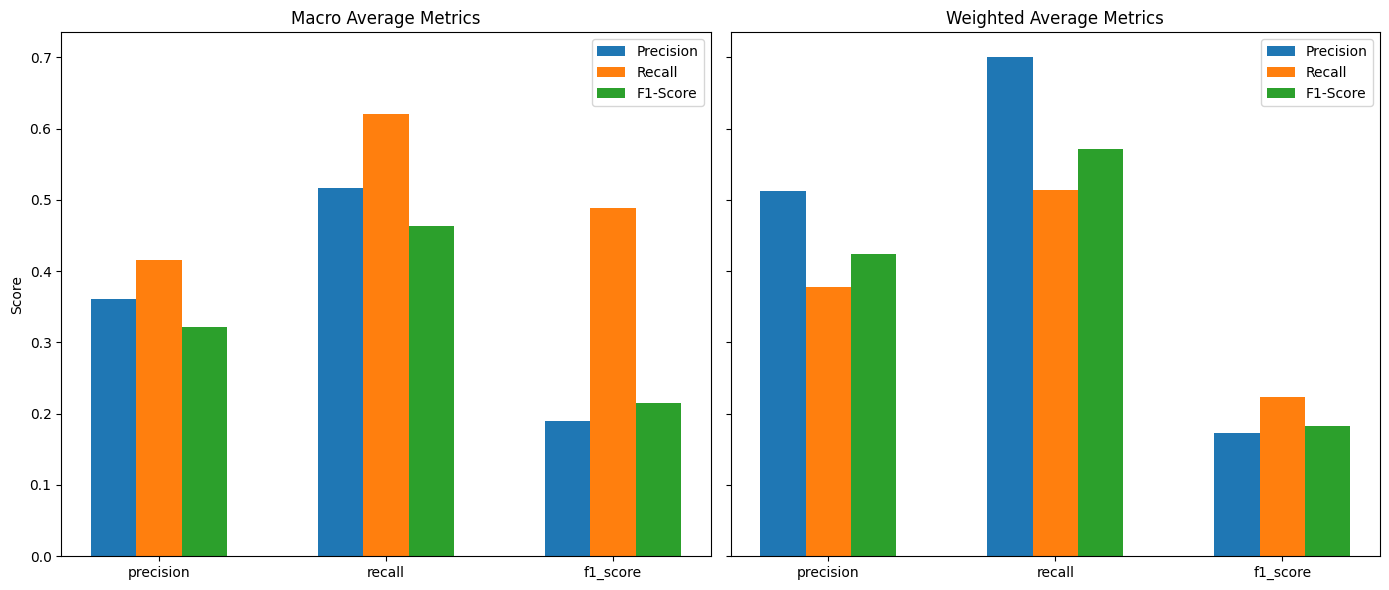

In [129]:
plot_df = df_all[df_all["label"].isin(["macro avg", "weighted avg"])]
x_tick_labels = ["precision", "recall", "f1_score"]


# Separate macro and weighted
macro_df = plot_df[plot_df['label'] == 'macro avg']
weighted_df = plot_df[plot_df['label'] == 'weighted avg']

# Set positions for bars
x = np.arange(3)  # number of models
width = 0.2  # width of each bar

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Macro avg plot
axes[0].bar(x - width, macro_df['precision'], width, label='Precision')
axes[0].bar(x, macro_df['recall'], width, label='Recall')
axes[0].bar(x + width, macro_df['f1-score'], width, label='F1-Score')
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_tick_labels)
axes[0].set_title('Macro Average Metrics')
axes[0].set_ylabel('Score')
axes[0].legend()

# Weighted avg plot
axes[1].bar(x - width, weighted_df['precision'], width, label='Precision')
axes[1].bar(x, weighted_df['recall'], width, label='Recall')
axes[1].bar(x + width, weighted_df['f1-score'], width, label='F1-Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_tick_labels)
axes[1].set_title('Weighted Average Metrics')
axes[1].legend()

plt.tight_layout()
plt.show()

### Which model to pick: VADER, RoBERTa or sentiment analysis pipeline? 
<b>What does each metric tell us?</b>
1. Precision: Out of all the rows that the model predicted to belong to a particular class, how many actually belonged to that class. Higher the precision, fewer the false positive values.
2. Recall : Out of all the rows belonging to a particular class, how many did the model correctly predict. Higher the recall, fewer the false negative values
3. F1 score: Harmonic mean of precision and recall. By nature, harmonic mean tends to incline toward the lower value. So, if a model has a lower precision, its F1 score will be lower to indicated that and the same goes for a lower recall model.

- In our case, we use F1 score and RoBERTa seems to dominate the F1 scores in both macroaverage and weighted average classes so I will pick that.